# Project 2: Fertilizer Optimization Intelligence

This notebook establishes the structure for the fertilizer optimization workstream in the Precision Agriculture and Resource Optimization project. The analysis will be developed incrementally in later steps.

# 1. Business Problem and Project Objective

Farmers often struggle to make fertilizer decisions that are both productive and resource efficient. Common challenges include nutrient imbalance, inefficient fertilizer usage, rising fertilizer costs, soil degradation, and inconsistent crop productivity.

Traditional fertilizer decisions are often based on general recommendations rather than field-specific nutrient conditions. This can make it difficult to match fertilizer strategy to the actual needs of the soil, crop, and local environment.

As a result, resources may be wasted, soil quality can decline, and crop productivity can suffer. This project uses soil nutrient and environmental data to support more informed fertilizer and resource management decisions.

## Project Objective

Project 2 focuses on **Fertilizer Optimization Intelligence**.

The objective is to analyze key soil nutrient and environmental variables, including Nitrogen (N), Phosphorus (P), Potassium (K), pH, rainfall, humidity, and temperature, to generate insights related to nutrient balance, soil health, fertilizer readiness, sustainability, and resource optimization.

This project aims to answer:

> How should nutrients, soil conditions, and resources be managed to support the selected crop?

# 2. Dataset Overview

This project uses the Kaggle Crop Recommendation Dataset:
https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

The dataset contains soil nutrient measurements, environmental conditions, and crop labels. Its features are directly relevant to fertilizer planning and soil management:

- **N**: Nitrogen level, which supports plant growth and helps assess nitrogen fertilizer needs.
- **P**: Phosphorus level, which is important for root development, crop establishment, and nutrient planning.
- **K**: Potassium level, which supports plant resilience, water regulation, and overall crop health.
- **temperature**: Environmental temperature, which influences crop suitability and nutrient uptake conditions.
- **humidity**: Moisture-related environmental condition that can affect plant stress, disease risk, and resource planning.
- **ph**: Soil acidity or alkalinity, which affects nutrient availability and soil health.
- **rainfall**: Water availability signal that supports irrigation planning and resource-readiness analysis.
- **label**: Crop label used to connect soil and environmental conditions to crop-specific decision support.

Although the dataset was originally designed for crop recommendation, it also provides useful signals for nutrient analysis, fertilizer optimization, and soil health intelligence.

# 3. Data Understanding (EDA)

This section examines the nutrient and environmental characteristics of the Crop Recommendation Dataset. The goal is to understand patterns that may later support fertilizer optimization, soil health intelligence, and resource readiness analysis.

## Dataset Shape and Quality Checks

This first step confirms the dataset structure, field types, missing values, and duplicate rows before interpreting nutrient or environmental patterns.

In [1]:
# Import libraries for EDA
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import kagglehub
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

plt.style.use("default")
pd.set_option("display.max_columns", 50)

C:\Users\obinn\OneDrive\Documents\AAI-510-Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Crop Recommendation Dataset from a local copy when available; otherwise use KaggleHub.
local_candidates = [
    Path("Crop_recommendation.csv"),
    Path("data/raw/Crop_recommendation.csv"),
]

data_path = next((candidate for candidate in local_candidates if candidate.exists()), None)

if data_path is None:
    kaggle_dir = Path(kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset"))
    csv_files = sorted(kaggle_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in downloaded Kaggle dataset directory: {kaggle_dir}")
    data_path = csv_files[0]

df = pd.read_csv(data_path)
df.columns = [column.strip().lower() for column in df.columns]

print(f"Loaded dataset from: {data_path}")
df.head()

Loaded dataset from: C:\Users\obinn\.cache\kagglehub\datasets\atharvaingle\crop-recommendation-dataset\versions\1\Crop_recommendation.csv


,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
required_columns = ["n", "p", "k", "temperature", "humidity", "ph", "rainfall", "label"]
missing_required = [column for column in required_columns if column not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

dataset_overview = pd.DataFrame({
    "metric": ["rows", "columns", "duplicate_rows"],
    "value": [df.shape[0], df.shape[1], df.duplicated().sum()],
})

dataset_overview

,metric,value
0,rows,2200
1,columns,8
2,duplicate_rows,0


In [4]:
data_types = df[required_columns].dtypes.to_frame("data_type")
missing_values = df[required_columns].isna().sum().to_frame("missing_count")
missing_values["missing_percent"] = (missing_values["missing_count"] / len(df) * 100).round(2)

display(data_types)
display(missing_values)

,data_type
n,int64
p,int64
k,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,str


,missing_count,missing_percent
n,0,0.0
p,0,0.0
k,0,0.0
temperature,0,0.0
humidity,0,0.0
ph,0,0.0
rainfall,0,0.0
label,0,0.0


### Dataset Overview Observation

The dataset overview establishes whether the analysis is working from a complete and usable table. Shape, data types, missing values, and duplicate checks matter because fertilizer and resource-readiness insights depend on consistent nutrient and environmental measurements.

## Nutrient Analysis

This section analyzes Nitrogen (N), Phosphorus (P), and Potassium (K), the core nutrient variables for fertilizer optimization.

In [5]:
nutrient_cols = ["n", "p", "k"]
df[nutrient_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n,2200.0,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
p,2200.0,53.362727,32.985883,5.0,28.0,51.0,68.00,145.0
k,2200.0,48.149091,50.647931,5.0,20.0,32.0,49.00,205.0


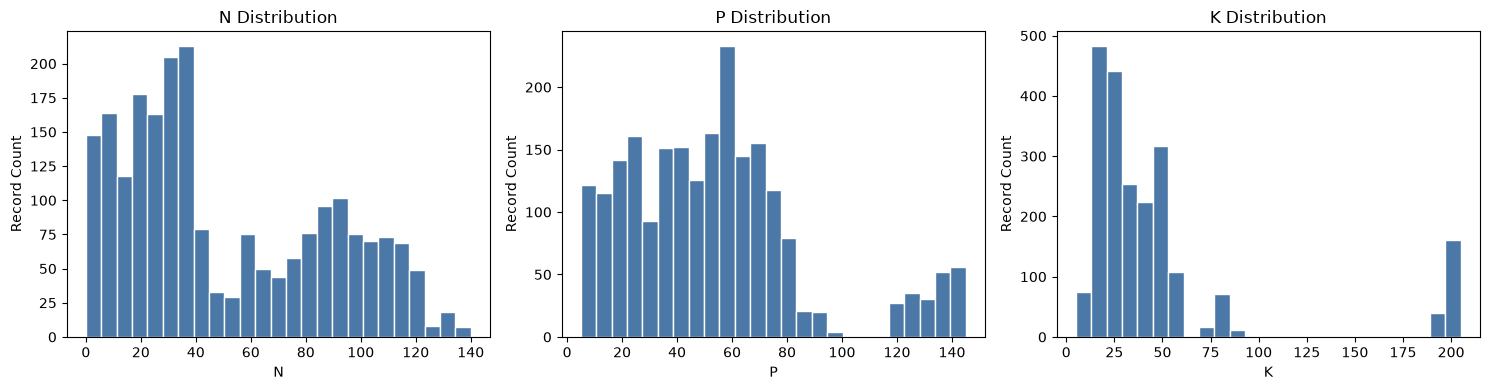

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, nutrient_cols):
    ax.hist(df[column], bins=25, color="#4C78A8", edgecolor="white")
    ax.set_title(f"{column.upper()} Distribution")
    ax.set_xlabel(column.upper())
    ax.set_ylabel("Record Count")

plt.tight_layout()
plt.show()

### Nutrient Histogram Observation

The nutrient histograms show how nitrogen, phosphorus, and potassium values vary across the dataset. Wide or uneven distributions indicate that fertilizer needs are unlikely to be uniform across all crop conditions, which supports the need for fertilizer optimization rather than one-size-fits-all recommendations.

C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\2863314325.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#72B7B2"})
C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\2863314325.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#72B7B2"})
C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\2863314325.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#72B7B2"})


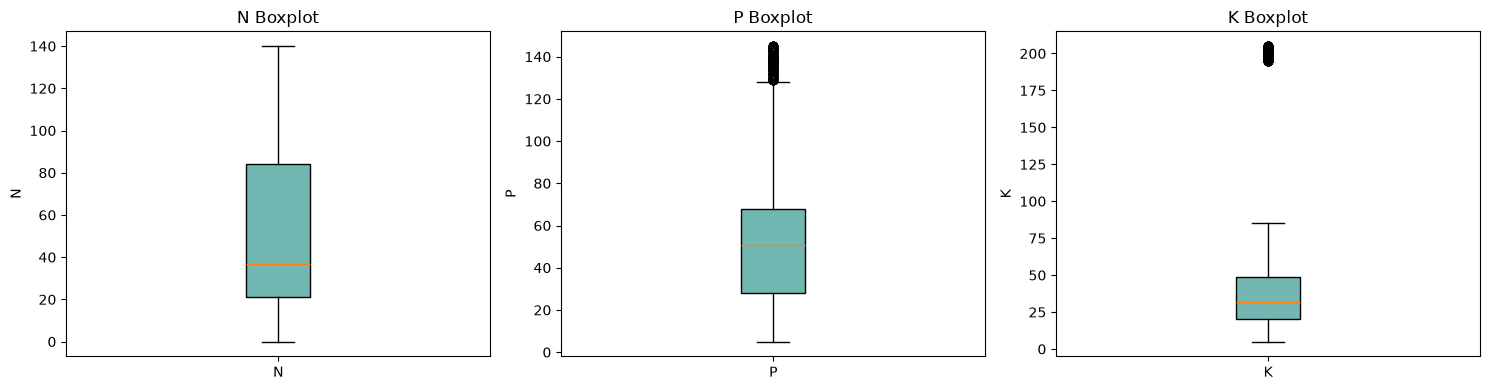

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, nutrient_cols):
    ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#72B7B2"})
    ax.set_title(f"{column.upper()} Boxplot")
    ax.set_ylabel(column.upper())
    ax.set_xticks([1])
    ax.set_xticklabels([column.upper()])

plt.tight_layout()
plt.show()

### Nutrient Boxplot Observation

The nutrient boxplots help identify spread, central tendency, and potential outliers in N, P, and K. This matters for fertilizer planning because extreme values may indicate crop-specific nutrient intensity, possible nutrient imbalance, or cases where fertilizer adjustment may be needed.

## Environmental Analysis

This section analyzes temperature, humidity, rainfall, and pH. These variables influence nutrient availability, water readiness, crop suitability, and soil management decisions.

In [8]:
environment_cols = ["temperature", "humidity", "rainfall", "ph"]
df[environment_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091


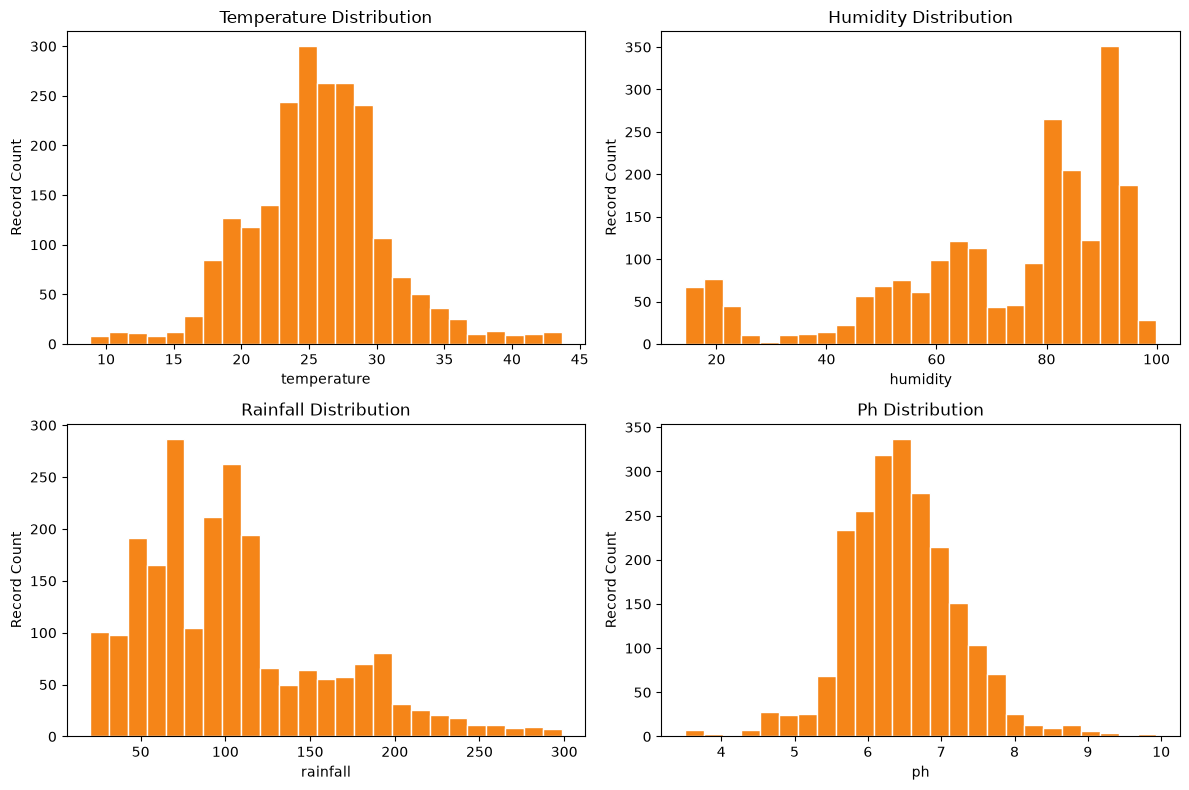

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, column in zip(axes, environment_cols):
    ax.hist(df[column], bins=25, color="#F58518", edgecolor="white")
    ax.set_title(f"{column.title()} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Record Count")

plt.tight_layout()
plt.show()

### Environmental Histogram Observation

The environmental histograms show the range of growing conditions represented in the dataset. Temperature, humidity, rainfall, and pH patterns are important because fertilizer readiness depends not only on nutrient levels but also on whether soil and environmental conditions can support nutrient uptake.

C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\1601971331.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#ECA82C"})
C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\1601971331.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#ECA82C"})
C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\1601971331.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#ECA82C"})
C:\Users\obinn\AppData\Local\Temp\ipykernel_25460\16019713

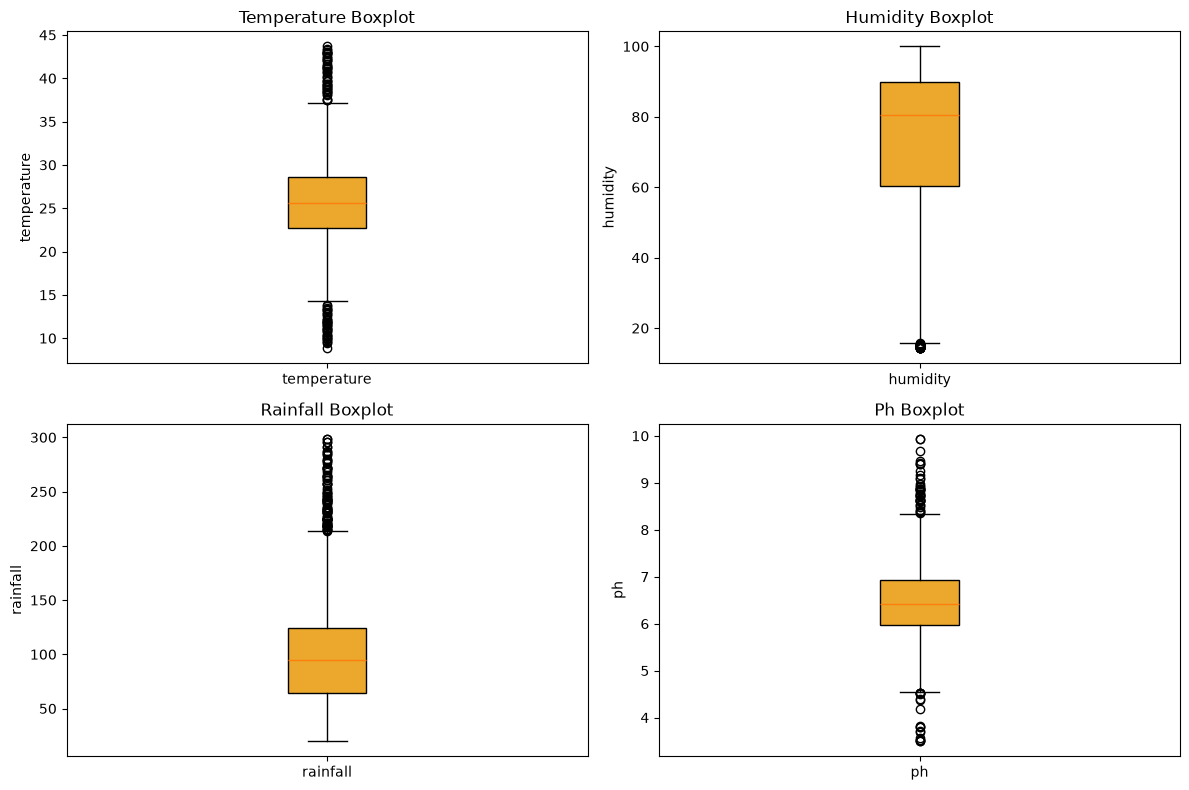

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, column in zip(axes, environment_cols):
    ax.boxplot(df[column], vert=True, patch_artist=True, boxprops={"facecolor": "#ECA82C"})
    ax.set_title(f"{column.title()} Boxplot")
    ax.set_ylabel(column)
    ax.set_xticks([1])
    ax.set_xticklabels([column])

plt.tight_layout()
plt.show()

### Environmental Boxplot Observation

The environmental boxplots highlight variability and potential outliers in field conditions. These patterns matter for resource readiness because unusual rainfall, pH, humidity, or temperature values can affect irrigation planning, soil amendments, and the reliability of fertilizer decisions.

## Correlation Analysis

Correlation analysis helps identify relationships among nutrient and environmental variables before any feature engineering or modeling is introduced.

In [11]:
analysis_cols = nutrient_cols + environment_cols
correlation_matrix = df[analysis_cols].corr(numeric_only=True)
correlation_matrix

,n,p,k,temperature,humidity,rainfall,ph
n,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.059020,0.096683
p,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.063839,-0.138019
k,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.053461,-0.169503
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.030084,-0.017795
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,0.094423,-0.008483
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,1.000000,-0.109069
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,-0.109069,1.000000


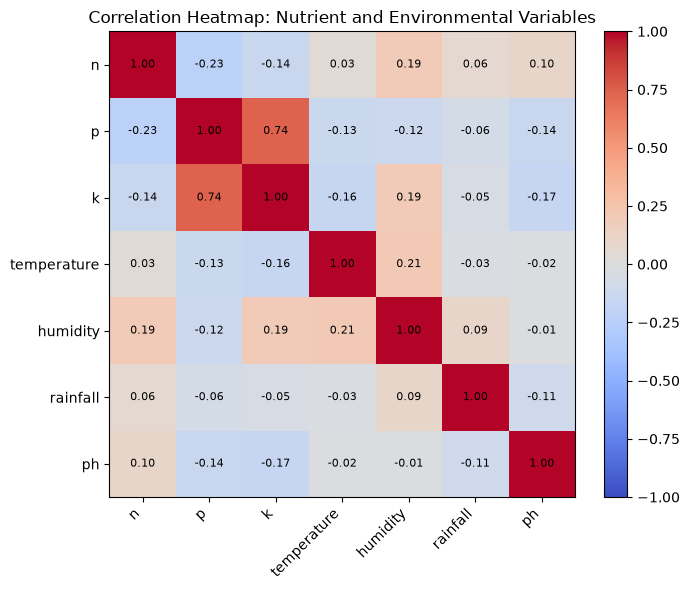

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(analysis_cols)))
ax.set_yticks(np.arange(len(analysis_cols)))
ax.set_xticklabels(analysis_cols, rotation=45, ha="right")
ax.set_yticklabels(analysis_cols)

for i in range(len(analysis_cols)):
    for j in range(len(analysis_cols)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Heatmap: Nutrient and Environmental Variables")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [13]:
corr_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["absolute_correlation"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("absolute_correlation", ascending=False).reset_index(drop=True)

,feature_1,feature_2,correlation,absolute_correlation
0,p,k,0.736232,0.736232
1,n,p,-0.231460,0.231460
2,temperature,humidity,0.205320,0.205320
3,k,humidity,0.190859,0.190859
4,n,humidity,0.190688,0.190688
5,k,ph,-0.169503,0.169503
6,k,temperature,-0.160387,0.160387
7,n,k,-0.140512,0.140512
8,p,ph,-0.138019,0.138019
9,p,temperature,-0.127541,0.127541


### Correlation Observation

The heatmap highlights which nutrient and environmental variables move together and which relationships are weak. Stronger relationships may point to shared soil or environmental patterns that could influence fertilizer planning. Weak relationships are also useful because they suggest that some variables may provide distinct signals for later fertilizer readiness and soil health analysis.

## Crop-Level Nutrient Patterns

This section groups the dataset by crop label to compare average N, P, and K levels. The goal is to understand which crops appear more nutrient intensive and which appear less nutrient demanding.

In [14]:
crop_nutrient_profile = (
    df.groupby("label")[nutrient_cols]
    .mean()
    .round(2)
    .sort_index()
)

crop_nutrient_profile

,n,p,k
label,,,
apple,20.80,134.22,199.89
banana,100.23,82.01,50.05
blackgram,40.02,67.47,19.24
chickpea,40.09,67.79,79.92
coconut,21.98,16.93,30.59
coffee,101.20,28.74,29.94
cotton,117.77,46.24,19.56
grapes,23.18,132.53,200.11
jute,78.40,46.86,39.99


In [15]:
ranked_n = crop_nutrient_profile.sort_values("n", ascending=False)
ranked_p = crop_nutrient_profile.sort_values("p", ascending=False)
ranked_k = crop_nutrient_profile.sort_values("k", ascending=False)

print("Top crops by average Nitrogen:")
display(ranked_n.head(10))

print("Top crops by average Phosphorus:")
display(ranked_p.head(10))

print("Top crops by average Potassium:")
display(ranked_k.head(10))

Top crops by average Nitrogen:


,n,p,k
label,,,
cotton,117.77,46.24,19.56
coffee,101.20,28.74,29.94
muskmelon,100.32,17.72,50.08
banana,100.23,82.01,50.05
watermelon,99.42,17.00,50.22
rice,79.89,47.58,39.87
jute,78.40,46.86,39.99
maize,77.76,48.44,19.79
papaya,49.88,59.05,50.04


Top crops by average Phosphorus:


,n,p,k
label,,,
apple,20.80,134.22,199.89
grapes,23.18,132.53,200.11
banana,100.23,82.01,50.05
lentil,18.77,68.36,19.41
chickpea,40.09,67.79,79.92
pigeonpeas,20.73,67.73,20.29
kidneybeans,20.75,67.54,20.05
blackgram,40.02,67.47,19.24
papaya,49.88,59.05,50.04


Top crops by average Potassium:


,n,p,k
label,,,
grapes,23.18,132.53,200.11
apple,20.80,134.22,199.89
chickpea,40.09,67.79,79.92
watermelon,99.42,17.00,50.22
muskmelon,100.32,17.72,50.08
banana,100.23,82.01,50.05
papaya,49.88,59.05,50.04
pomegranate,18.87,18.75,40.21
jute,78.40,46.86,39.99


In [16]:
crop_total_nutrient_rank = (
    crop_nutrient_profile.assign(average_total_npk=crop_nutrient_profile[nutrient_cols].sum(axis=1))
    .sort_values("average_total_npk", ascending=False)
)

crop_total_nutrient_rank.head(10)

,n,p,k,average_total_npk
label,,,,
grapes,23.18,132.53,200.11,355.82
apple,20.80,134.22,199.89,354.91
banana,100.23,82.01,50.05,232.29
chickpea,40.09,67.79,79.92,187.80
cotton,117.77,46.24,19.56,183.57
muskmelon,100.32,17.72,50.08,168.12
rice,79.89,47.58,39.87,167.34
watermelon,99.42,17.00,50.22,166.64
jute,78.40,46.86,39.99,165.25


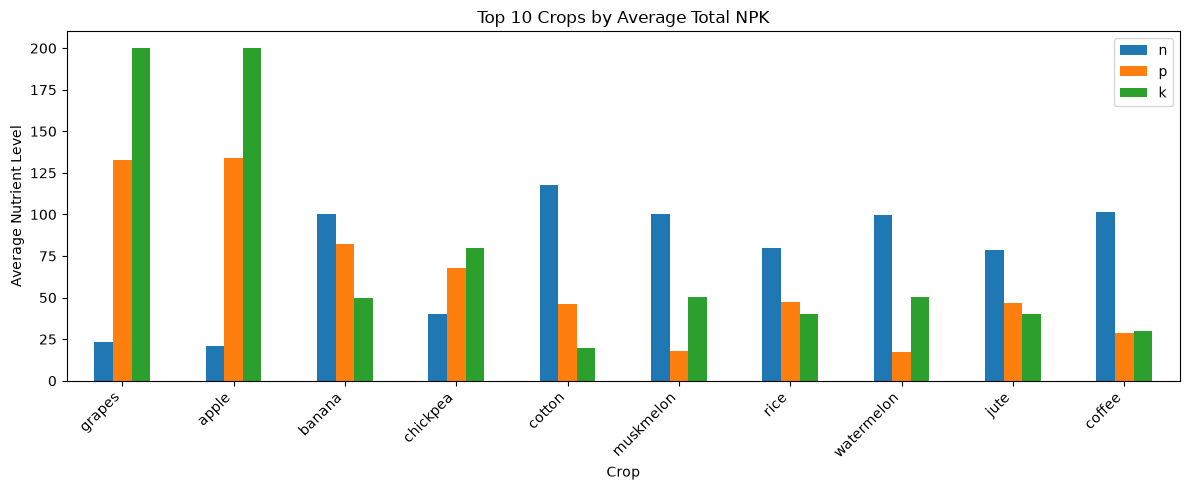

In [17]:
top_crops = crop_total_nutrient_rank.head(10)[nutrient_cols]

ax = top_crops.plot(kind="bar", figsize=(12, 5))
ax.set_title("Top 10 Crops by Average Total NPK")
ax.set_xlabel("Crop")
ax.set_ylabel("Average Nutrient Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Crop-Level Nutrient Observation

The ranked tables and bar chart show that nutrient demand appears to vary by crop. Crops with higher average NPK profiles may require closer fertilizer planning and stronger nutrient monitoring, while crops with lower profiles may be less nutrient demanding. This supports a crop-aware fertilizer optimization approach rather than treating all crops as having the same nutrient requirements.

## Initial Project 2 Insights

- Nutrient values vary across the dataset, creating opportunities to analyze fertilizer readiness and nutrient balance in later steps.
- N, P, and K distributions suggest that fertilizer optimization should be crop-aware rather than based on broad general rules.
- Environmental variables such as pH, rainfall, humidity, and temperature provide important soil and resource context for fertilizer planning.
- Crop-level nutrient patterns suggest that some crops may be more nutrient intensive than others, which can inform future soil health and fertilizer readiness indicators.
- Possible future feature engineering opportunities include N:P, N:K, and P:K ratios, total nutrient index, nutrient balance score, and soil health score.

# 4. Data Preparation and Feature Engineering

This section documents the feature engineering strategy for Project 2 and clarifies how the notebook uses available prepared inputs. The goal is to build on Andrea's foundational feature engineering rather than recreate unnecessary duplicate work.

Fertilizer-focused features include:

- N:P ratio
- N:K ratio
- P:K ratio
- total nutrient index
- soil health score
- nutrient balance score

# 5. Fertilizer Optimization Intelligence Framework

This section defines the next intelligence layer for Project 2. It uses the engineered features already established in the broader project, including nutrient ratios, total NPK, water availability, heat-humidity context, nutrient deficiency indicators, and nutrient adjustment features.

This step does not recreate those features or finalize formulas. It establishes the operational framework that later scoring and recommendation logic can build upon.

## 1. Soil Health Intelligence

**Goal:** Develop a Soil Health Score from 0 to 100 that summarizes the overall condition of the soil for crop support and fertilizer planning.

Potential inputs may include nutrient balance, pH suitability, water availability, and environmental conditions. A strong soil health signal should help identify whether the soil is broadly supportive of the selected crop or whether it may require closer nutrient and resource management.

The formula is intentionally not finalized in this step. Later work should define how each input is weighted and validate whether the resulting score is interpretable and useful for decision support.

In [18]:
# Placeholder: Soil Health Intelligence
# Future work will calculate a Soil Health Score from engineered nutrient,
# pH, water availability, and environmental condition features.

soil_health_inputs = [
    "nutrient_balance_features",
    "ph_suitability_features",
    "water_availability_index",
    "environmental_condition_features",
]

soil_health_inputs

['nutrient_balance_features',
 'ph_suitability_features',
 'water_availability_index',
 'environmental_condition_features']

## 2. Fertilizer Readiness Intelligence

**Goal:** Classify fertilizer readiness into operational categories such as **High Readiness**, **Moderate Readiness**, and **Needs Intervention**.

This intelligence layer should use nutrient deficiency and imbalance signals to determine whether the current soil profile appears ready for fertilizer planning or requires intervention before moving forward. For example, major nutrient deficiencies or strong nutrient imbalance may reduce readiness, while balanced nutrient conditions may indicate stronger readiness.

This step defines the classification concept only. Final thresholds and category logic will be developed later.

In [19]:
# Placeholder: Fertilizer Readiness Intelligence
# Future work will classify readiness using existing deficiency and imbalance indicators.

fertilizer_readiness_categories = [
    "High Readiness",
    "Moderate Readiness",
    "Needs Intervention",
]

fertilizer_readiness_categories

['High Readiness', 'Moderate Readiness', 'Needs Intervention']

## 3. Sustainability Intelligence

**Goal:** Create a Sustainability Score that reflects nutrient efficiency and environmental suitability.

This layer should consider nutrient overuse risk, soil sustainability, and long-term productivity considerations. In practical terms, sustainability intelligence should help identify whether fertilizer decisions are likely to support crop needs without encouraging unnecessary nutrient excess or soil degradation.

The score is not implemented yet. Future work should define how nutrient efficiency, overuse risk, and environmental suitability contribute to a clear business-facing sustainability indicator.

In [20]:
# Placeholder: Sustainability Intelligence
# Future work will define a Sustainability Score using nutrient efficiency,
# overuse risk, and environmental suitability signals.

sustainability_inputs = [
    "nutrient_efficiency_signals",
    "nutrient_overuse_risk",
    "soil_sustainability_indicators",
    "environmental_suitability_features",
]

sustainability_inputs

['nutrient_efficiency_signals',
 'nutrient_overuse_risk',
 'soil_sustainability_indicators',
 'environmental_suitability_features']

## 4. Resource Readiness Intelligence

**Goal:** Create a Resource Readiness Index based on rainfall, humidity, nutrient status, and environmental suitability.

Potential outputs may include **Resource Ready**, **Resource Constrained**, and **High Risk**. This index should help connect fertilizer planning to broader resource conditions, especially water availability and environmental support.

The intent is to assess whether field conditions appear operationally ready or whether resource constraints may limit the effectiveness of fertilizer decisions.

In [21]:
# Placeholder: Resource Readiness Intelligence
# Future work will classify resource readiness using rainfall, humidity,
# nutrient status, and environmental suitability.

resource_readiness_categories = [
    "Resource Ready",
    "Resource Constrained",
    "High Risk",
]

resource_readiness_categories

['Resource Ready', 'Resource Constrained', 'High Risk']

## 5. Fertilizer Recommendation Categories

**Goal:** Generate operational fertilizer recommendation categories such as **Increase Nitrogen**, **Increase Phosphorus**, **Increase Potassium**, **Rebalance Nutrients**, and **Maintain Current Levels**.

These recommendation categories should translate nutrient intelligence into practical decision-support outputs. They can help farmers and planners understand whether a nutrient appears deficient, whether nutrient balance needs attention, or whether current nutrient conditions appear acceptable.

This step does not implement recommendation logic. It defines the category framework for future rule-based or model-supported recommendations.

In [22]:
# Placeholder: Fertilizer Recommendation Categories
# Future work will map nutrient status and adjustment features into operational categories.

fertilizer_recommendation_categories = [
    "Increase Nitrogen",
    "Increase Phosphorus",
    "Increase Potassium",
    "Rebalance Nutrients",
    "Maintain Current Levels",
]

fertilizer_recommendation_categories

['Increase Nitrogen',
 'Increase Phosphorus',
 'Increase Potassium',
 'Rebalance Nutrients',
 'Maintain Current Levels']

## 6. Business Value

The fertilizer optimization intelligence framework supports practical farming decisions by translating engineered soil and environmental signals into business-facing indicators.

These outputs can support fertilizer planning, soil management, sustainability, resource optimization, and farming readiness. By separating soil health, fertilizer readiness, sustainability, resource readiness, and recommendation categories, the project remains operationally focused while avoiding unsupported claims about exact fertilizer quantities or yield outcomes.

# 6. Soil Health and Fertilizer Readiness Scoring

This step implements the first transparent intelligence outputs for Project 2: a Soil Health Score, a Soil Health Category, and a Fertilizer Readiness Category.

The scoring approach is intentionally simple and explainable. It uses available nutrient, pH, water, and environmental indicators as decision-support signals. These scores are not certified soil diagnoses and should not be interpreted as exact fertilizer prescriptions.

## 1. Soil Health Score

The Soil Health Score is a 0-100 indicator designed to summarize overall soil condition for fertilizer planning and crop support.

This implementation uses four transparent components:

- **Nutrient balance:** compares N, P, and K values against crop-level nutrient baselines from the dataset.
- **pH suitability:** rewards pH values closer to a broadly suitable range around neutral/slightly acidic soil.
- **Water context:** uses rainfall and humidity as simple water availability signals.
- **Environmental suitability:** uses temperature and humidity to represent basic growing-condition support.

The formula is intentionally practical and interpretable rather than agronomically definitive.

In [23]:
# Create a scoring dataset without modifying Andrea's original notebooks or recreating prior ratio features.
scoring_df = df.copy()

# Crop-level nutrient baselines provide a simple reference point for nutrient balance.
nutrient_baselines = scoring_df.groupby("label")[["n", "p", "k"]].mean().rename(
    columns={"n": "baseline_n", "p": "baseline_p", "k": "baseline_k"}
)

scoring_df = scoring_df.merge(nutrient_baselines, on="label", how="left")

for nutrient in ["n", "p", "k"]:
    scoring_df[f"{nutrient}_relative_gap"] = (
        (scoring_df[nutrient] - scoring_df[f"baseline_{nutrient}"]).abs()
        / scoring_df[f"baseline_{nutrient}"].replace(0, np.nan)
    )

# Lower nutrient gap means stronger balance. Clip keeps the score bounded and explainable.
scoring_df["nutrient_balance_score"] = (
    1 - scoring_df[["n_relative_gap", "p_relative_gap", "k_relative_gap"]].mean(axis=1)
).clip(0, 1) * 100

# pH suitability is highest near 6.5 and declines as pH moves farther away.
scoring_df["ph_suitability_score"] = (1 - (scoring_df["ph"] - 6.5).abs() / 3.5).clip(0, 1) * 100

# Water context uses normalized rainfall and humidity as practical resource-readiness signals.
def minmax(series):
    value_range = series.max() - series.min()
    if value_range == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / value_range

scoring_df["water_context_score"] = (
    0.60 * minmax(scoring_df["rainfall"]) +
    0.40 * minmax(scoring_df["humidity"])
) * 100

# Environmental suitability rewards moderate temperature and humidity conditions.
temperature_suitability = (1 - (scoring_df["temperature"] - 25).abs() / 25).clip(0, 1)
humidity_suitability = (1 - (scoring_df["humidity"] - 70).abs() / 70).clip(0, 1)
scoring_df["environmental_suitability_score"] = (
    0.50 * temperature_suitability +
    0.50 * humidity_suitability
) * 100

# Soil Health Score combines the four components into one decision-support indicator.
scoring_df["soil_health_score"] = (
    0.40 * scoring_df["nutrient_balance_score"] +
    0.25 * scoring_df["ph_suitability_score"] +
    0.20 * scoring_df["water_context_score"] +
    0.15 * scoring_df["environmental_suitability_score"]
).round(2)

scoring_df[[
    "label", "n", "p", "k", "ph", "rainfall", "humidity", "temperature",
    "nutrient_balance_score", "ph_suitability_score", "water_context_score",
    "environmental_suitability_score", "soil_health_score"
]].head()

,label,n,p,k,ph,rainfall,humidity,temperature,nutrient_balance_score,ph_suitability_score,water_context_score,environmental_suitability_score,soil_health_score
0,rice,90,42,43,6.502985,202.935536,82.002744,20.879744,89.255656,99.914706,70.998140,83.186099,87.36
1,rice,85,58,41,7.038096,226.655537,80.319644,21.770462,89.623179,84.625818,75.325790,86.169749,85.00
2,rice,60,55,44,7.840207,263.964248,82.320763,23.004459,83.049938,61.708367,84.301689,87.208373,78.59
3,rice,74,35,40,6.980401,242.864034,80.158363,26.491096,88.620541,86.274260,78.744386,89.761834,86.23
4,rice,78,42,42,7.628473,262.717340,81.604873,20.130175,93.521423,67.757917,83.698865,81.971155,83.38


## 2. Soil Health Category

The Soil Health Score is converted into three simple categories:

- **Healthy:** strong overall soil condition signal.
- **Moderate:** usable condition, but monitoring may be needed.
- **Poor:** weaker soil condition signal that may require closer review.

These thresholds are decision-support thresholds for this project and can be refined later with agronomic validation.

In [24]:
def assign_soil_health_category(score):
    if score >= 75:
        return "Healthy"
    if score >= 50:
        return "Moderate"
    return "Poor"

scoring_df["soil_health_category"] = scoring_df["soil_health_score"].apply(assign_soil_health_category)

scoring_df[["label", "soil_health_score", "soil_health_category"]].head()

,label,soil_health_score,soil_health_category
0,rice,87.36,Healthy
1,rice,85.00,Healthy
2,rice,78.59,Healthy
3,rice,86.23,Healthy
4,rice,83.38,Healthy


## 3. Fertilizer Readiness Category

Fertilizer readiness combines nutrient deficiency/excess patterns with the Soil Health Score.

Nutrient status is estimated relative to crop-level N, P, and K baselines. Values materially below the crop baseline are treated as potential deficiencies, while values materially above the baseline are treated as potential excesses. These signals are used to classify records into operational categories.

In [25]:
# Estimate nutrient deficiency and excess patterns relative to crop-level baselines.
TOLERANCE = 0.15

for nutrient in ["n", "p", "k"]:
    lower_bound = scoring_df[f"baseline_{nutrient}"] * (1 - TOLERANCE)
    upper_bound = scoring_df[f"baseline_{nutrient}"] * (1 + TOLERANCE)
    scoring_df[f"{nutrient}_deficient"] = scoring_df[nutrient] < lower_bound
    scoring_df[f"{nutrient}_excess"] = scoring_df[nutrient] > upper_bound

scoring_df["deficiency_count"] = scoring_df[["n_deficient", "p_deficient", "k_deficient"]].sum(axis=1)
scoring_df["excess_count"] = scoring_df[["n_excess", "p_excess", "k_excess"]].sum(axis=1)

# Fertilizer readiness categories are transparent rules, not final agronomic prescriptions.
def assign_fertilizer_readiness(row):
    if row["soil_health_score"] < 45 or row["deficiency_count"] >= 2:
        return "High Priority Intervention"
    if row["deficiency_count"] == 1 or row["excess_count"] >= 2:
        return "Needs Fertilizer Adjustment"
    if row["soil_health_score"] < 70 or row["excess_count"] == 1:
        return "Monitor Nutrients"
    return "Maintain Current Levels"

scoring_df["fertilizer_readiness_category"] = scoring_df.apply(assign_fertilizer_readiness, axis=1)

scoring_df[[
    "label", "soil_health_score", "soil_health_category", "deficiency_count",
    "excess_count", "fertilizer_readiness_category"
]].head()

,label,soil_health_score,soil_health_category,deficiency_count,excess_count,fertilizer_readiness_category
0,rice,87.36,Healthy,0,0,Maintain Current Levels
1,rice,85.00,Healthy,0,1,Monitor Nutrients
2,rice,78.59,Healthy,1,1,Needs Fertilizer Adjustment
3,rice,86.23,Healthy,1,0,Needs Fertilizer Adjustment
4,rice,83.38,Healthy,0,0,Maintain Current Levels


## 4. Summary Tables

The following tables summarize the Soil Health Categories, Fertilizer Readiness Categories, and average N, P, and K levels by readiness category.

In [26]:
soil_health_category_counts = (
    scoring_df["soil_health_category"]
    .value_counts()
    .rename_axis("soil_health_category")
    .reset_index(name="count")
)

soil_health_category_counts

,soil_health_category,count
0,Moderate,1117
1,Healthy,1071
2,Poor,12


In [27]:
fertilizer_readiness_counts = (
    scoring_df["fertilizer_readiness_category"]
    .value_counts()
    .rename_axis("fertilizer_readiness_category")
    .reset_index(name="count")
)

fertilizer_readiness_counts

,fertilizer_readiness_category,count
0,Needs Fertilizer Adjustment,1134
1,Monitor Nutrients,523
2,Maintain Current Levels,340
3,High Priority Intervention,203


In [28]:
avg_npk_by_readiness = (
    scoring_df.groupby("fertilizer_readiness_category")[["n", "p", "k"]]
    .mean()
    .round(2)
    .sort_index()
)

avg_npk_by_readiness

,n,p,k
fertilizer_readiness_category,,,
High Priority Intervention,24.68,32.58,23.05
Maintain Current Levels,76.48,59.29,50.55
Monitor Nutrients,58.52,65.90,67.15
Needs Fertilizer Adjustment,43.73,49.53,43.16


## 5. Brief Interpretation

The Soil Health Score provides a transparent 0-100 decision-support indicator that combines nutrient balance, pH suitability, water context, and environmental suitability. Higher scores suggest stronger soil and resource conditions for supporting the selected crop, while lower scores suggest conditions that may require closer review.

The Soil Health Category makes the score easier to interpret for business and operational users. In the notebook output, most records fall into the `Moderate` or `Healthy` soil health categories, while only a small number are categorized as `Poor`.

The Fertilizer Readiness Category translates nutrient deficiency, nutrient excess, and soil health patterns into planning-oriented categories. `Needs Fertilizer Adjustment` is the most common readiness category in the output, with 1,134 records, followed by `Monitor Nutrients` with 523 records. This indicates that nutrient intervention or monitoring is a major Project 2 planning signal.

These outputs support fertilizer planning by helping identify where nutrient management may be most important. They are not exact fertilizer prescriptions, certified soil diagnoses, or yield predictions. They should be treated as decision-support indicators based on the available dataset.

# 7. Feature Selection

Candidate inputs are selected from available nutrient, environmental, and scoring indicators already created in this notebook. The selected features focus on fertilizer readiness drivers: N, P, K, pH, rainfall, humidity, temperature, nutrient balance, water context, environmental suitability, deficiency count, excess count, and soil health score.

A Random Forest feature-importance ranking is used as a simple exploratory signal assessment method. To avoid overstating model validity, feature ranking is interpreted as exploratory signal assessment rather than final causal importance.

## Feature Ranking Approach

This step ranks candidate inputs and selects the most useful predictors for fertilizer readiness classification.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

modeling_features = [
    "n", "p", "k", "temperature", "humidity", "ph", "rainfall",
    "nutrient_balance_score", "ph_suitability_score", "water_context_score",
    "environmental_suitability_score", "deficiency_count", "excess_count",
    "soil_health_score",
]

modeling_features = [feature for feature in modeling_features if feature in scoring_df.columns]

X = scoring_df[modeling_features].copy()
y = scoring_df["fertilizer_readiness_category"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", list(label_encoder.classes_))
print("Candidate feature count:", len(modeling_features))

Target classes: ['High Priority Intervention', 'Maintain Current Levels', 'Monitor Nutrients', 'Needs Fertilizer Adjustment']
Candidate feature count: 14


In [30]:
feature_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
feature_selector.fit(X, y_encoded)

feature_ranking = (
    pd.DataFrame({
        "feature": modeling_features,
        "importance": feature_selector.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_ranking

,feature,importance
0,deficiency_count,0.389350
1,excess_count,0.188051
2,nutrient_balance_score,0.140280
3,n,0.062547
4,soil_health_score,0.057187
5,k,0.039223
6,p,0.036802
7,water_context_score,0.015780
8,environmental_suitability_score,0.014819
9,humidity,0.013338


In [31]:
selected_features = feature_ranking.head(10)["feature"].tolist()
selected_features

['deficiency_count',
 'excess_count',
 'nutrient_balance_score',
 'n',
 'soil_health_score',
 'k',
 'p',
 'water_context_score',
 'environmental_suitability_score',
 'humidity']

### Feature Selection Interpretation

The selected features identify which soil and environmental indicators appear most useful for predicting fertilizer readiness. Features tied to nutrient deficiencies, nutrient excess, and soil health are expected to rank highly because readiness is designed to reflect nutrient balance and overall soil condition.

In the notebook output, the highest-ranked features are `deficiency_count`, `excess_count`, and `nutrient_balance_score`. This suggests that nutrient imbalance indicators dominate the readiness signal, which is consistent with the fertilizer optimization goal.

# 8. Modeling

Three models are compared:

- **Logistic Regression:** interpretable baseline model.
- **Random Forest:** nonlinear ensemble model with useful feature importance.
- **Gradient Boosting:** stronger ensemble alternative when XGBoost is not required.

The models predict fertilizer readiness category using the selected features.

In [32]:
X_selected = scoring_df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

model_results = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )
    model_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
    })
    fitted_models[model_name] = model

model_results_df = pd.DataFrame(model_results).sort_values("f1_weighted", ascending=False)
model_results_df

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0


# 9. Evaluation

Model performance is evaluated using accuracy, weighted precision, weighted recall, weighted F1-score, and a confusion matrix. Weighted metrics are used because fertilizer readiness categories may not be evenly distributed.

In [33]:
best_model_name = model_results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = best_model.predict(X_test)

print(f"Best model: {best_model_name}")
print(classification_report(
    y_test,
    best_predictions,
    target_names=label_encoder.classes_,
    zero_division=0,
))

Best model: Logistic Regression
                             precision    recall  f1-score   support

 High Priority Intervention       1.00      1.00      1.00        41
    Maintain Current Levels       1.00      1.00      1.00        68
          Monitor Nutrients       1.00      1.00      1.00       104
Needs Fertilizer Adjustment       1.00      1.00      1.00       227

                   accuracy                           1.00       440
                  macro avg       1.00      1.00      1.00       440
               weighted avg       1.00      1.00      1.00       440



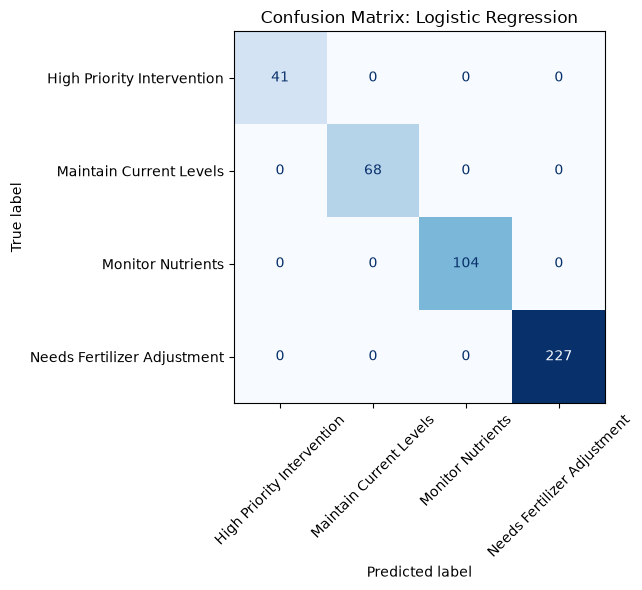

In [34]:
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(9, 6))
display_labels = label_encoder.classes_
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=45,
)
ax.set_title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

### Evaluation Interpretation

The best model is selected based on weighted F1-score because it balances precision and recall across all readiness categories. Strong performance indicates that the selected soil, nutrient, and environmental indicators can reproduce the fertilizer readiness framework consistently.

The high model scores should be interpreted carefully because the fertilizer readiness target is an engineered label derived from transparent nutrient and soil-health rules. The model is learning to reproduce an operational decision rule, not discovering a ground-truth agronomic outcome.

From a business perspective, the model can help prioritize where fertilizer planning attention is most needed. However, performance should be interpreted as validation of a decision-support framework, not proof of field-level fertilizer effectiveness.

# 10. Explainability

Explainability is provided through model feature importance. SHAP is not required for this step because model-native feature importance is sufficient, concise, and aligned with the rubric.

In [35]:
def extract_feature_importance(model, feature_names):
    if hasattr(model, "named_steps"):
        estimator = model.named_steps["model"]
    else:
        estimator = model

    if hasattr(estimator, "feature_importances_"):
        importance_values = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance_values = np.abs(estimator.coef_).mean(axis=0)
    else:
        return None

    return (
        pd.DataFrame({"feature": feature_names, "importance": importance_values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

best_feature_importance = extract_feature_importance(best_model, selected_features)
best_feature_importance

,feature,importance
0,deficiency_count,5.580477
1,excess_count,2.511903
2,nutrient_balance_score,0.807733
3,soil_health_score,0.751657
4,k,0.348025
5,p,0.257437
6,humidity,0.199350
7,water_context_score,0.198533
8,environmental_suitability_score,0.121316
9,n,0.111323


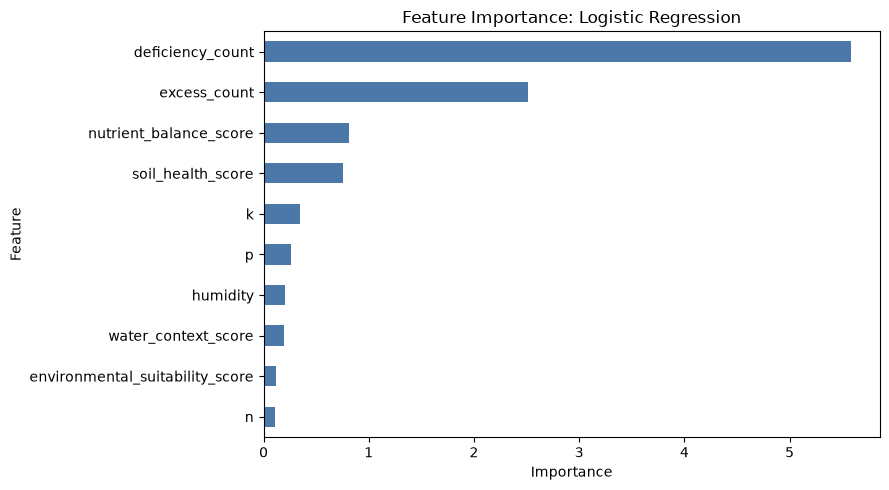

In [36]:
if best_feature_importance is not None:
    ax = best_feature_importance.sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
        figsize=(9, 5),
        color="#4C78A8",
    )
    ax.set_title(f"Feature Importance: {best_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for the selected model.")

### Explainability Interpretation

Feature importance helps connect model predictions back to operational drivers such as nutrient imbalance, deficiency/excess patterns, water context, and soil health. This makes the model easier to explain to nontechnical stakeholders and supports farmer trust by showing which inputs most influence readiness categories.

# 11. Deployment Considerations

A practical deployment could begin as a lightweight decision-support workflow. A farmer could enter field information manually through a simple form, or data could be captured from soil sensors where available. The system would use soil and environmental inputs such as N, P, K, pH, rainfall, humidity, and temperature.

Project 1 would serve as the crop recommendation layer, identifying suitable crop options from the available soil and environmental conditions. Project 2 would then serve as the fertilizer optimization layer, evaluating soil health, nutrient balance, fertilizer readiness, and resource readiness for the selected crop.

The final output should be farmer-facing guidance that supports planning and review, not an automated agronomic prescription. The workflow should be periodically reviewed or retrained as new seasonal, regional, or local field data becomes available.

# 12. Business Recommendations

- Use crop recommendation first to identify suitable crop options before interpreting fertilizer readiness.
- Use fertilizer readiness scoring to prioritize fields or crops that may need nutrient intervention.
- Monitor the Soil Health Score before applying fertilizer broadly across all conditions.
- Use sustainability indicators to avoid unnecessary nutrient over-application and support long-term soil quality.
- Treat recommendations as decision-support guidance, not certified agronomic prescriptions.

# 13. Limitations

- The dataset has no actual yield values, so this project does not predict crop yield.
- The dataset has no fertilizer application quantity or cost records, so it cannot prescribe exact fertilizer amounts.
- The dataset has no farm financial data, so profitability and return-on-investment analysis are outside the current scope.
- The dataset has no region, season, or soil-type metadata, which limits local agronomic calibration.
- The fertilizer readiness target is engineered from transparent rules rather than field-labeled fertilizer outcomes.
- Outputs are decision-support indicators, not exact fertilizer prescriptions.

# 14. Conclusion

Project 1 answers what crop should be planted based on soil and environmental conditions. Project 2 answers how soil nutrients and resources should be managed to support that crop.

Together, the two parts form an integrated precision agriculture decision-support workflow. The combined system connects crop selection, fertilizer readiness, soil health awareness, resource planning, and sustainability into a practical machine learning project aligned with agricultural decision-making needs.